In [102]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [103]:
import os, sys
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import pandas as pd
from geodatasets import get_path
import ast
# import geopy.distances
from tqdm import tqdm

import matplotlib as mpl
from matplotlib.colors import ListedColormap
sys.path.append('../src/')
sys.path.append('../content/')
import data_utils as du
import vis_utils as vu
import sample_locations as sl

## Set `data_folder` and plot example:

In [104]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'

list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.
Number of samples: 18393


(lat, lon) = (6.879824490613634, 9.73940860503498)


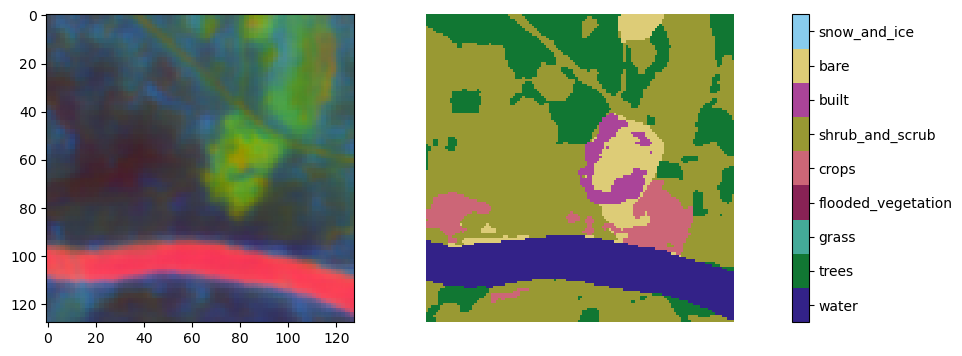

In [44]:

id = list_ids[324]

ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')

fig, ax = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1, 0.05]})
vu.plot_dw_landcover_from_hyp(dw[:, :, :], ax=ax[1], cax=ax[2], fig=fig)
vu.plot_simple_overview_embeddings(ae, method='pca', bands=(3, 4, 5), ax=ax[0])

curr_coords = gdf_points[gdf_points.id == id][['lat', 'lon']]
print(f'(lat, lon) = ({curr_coords.lat.values[0]}, {curr_coords.lon.values[0]})')

## Extract centre only

In [29]:
du.create_csv_with_points_from_patches(parent_folder=data_folder)

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


100%|██████████| 18969/18969 [01:57<00:00, 161.19it/s]


In [17]:
patch_size = 128
AE_COLS = [f'ae_{i}' for i in range(ae.shape[0])]
cols = ['id','pix_x', 'pix_y', 'random_sample', 'lc_stratified_sample'] + du.DW_CLASSES + AE_COLS
results = {x: [] for x in cols}
x, y = 64, 64
for id in tqdm(list_ids[:]):
    ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
    dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')
    bool_random = gdf_points[gdf_points.id == id]['random_sample'].values[0]
    bool_strat = gdf_points[gdf_points.id == id]['lc_stratified_sample'].values[0]
    
    dw_patch = dw[:, y, x]
    ae_patch = ae[:, y, x]
    results['id'].append(id)
    results['pix_x'].append(x)
    results['pix_y'].append(y)
    results['random_sample'].append(bool_random)
    results['lc_stratified_sample'].append(bool_strat)

    for j, c in enumerate(du.DW_CLASSES):
        results[c].append(dw_patch[j])
    for j in range(ae.shape[0]):
        results[f'ae_{j}'].append(ae_patch[j])

df_results_centre = pd.DataFrame(results)


100%|██████████| 18393/18393 [02:38<00:00, 116.23it/s]


In [23]:
df_tmp = df_results_centre[df_results_centre.random_sample == True]
df_tmp = df_tmp[[c for c in df_tmp.columns if c.startswith('ae_')] + ['id']]
df_tmp.reset_index(drop=True, inplace=True)
df_tmp = df_tmp.rename(columns={c: c.replace('ae_', 'emb_') for c in df_tmp.columns if c.startswith('ae_')})
# df_tmp.to_csv(os.path.join(data_folder, 'random_sample_alphaearth_centre.csv'), index=False)

## Extract random pixels:


In [123]:
n_random_per_patch = 10 
patch_size = 128
AE_COLS = [f'ae_{i}' for i in range(ae.shape[0])]
cols = ['id','pix_x', 'pix_y', 'random_sample', 'lc_stratified_sample'] + du.DW_CLASSES + AE_COLS
results = {x: [] for x in cols}
for id in list_ids[:]:
    ae = du.load_tiff(os.path.join(data_folder, 'alphaearth', f'{id}_alphaearth_y-2024.tif'), datatype='np')
    dw = du.load_tiff(os.path.join(data_folder, 'dynamicworld', f'{id}_dynamicworld_y-2024.tif'), datatype='np')
    bool_random = gdf_points[gdf_points.id == id]['random_sample'].values[0]
    bool_strat = gdf_points[gdf_points.id == id]['lc_stratified_sample'].values[0]
    selected = set() 
    for i in range(n_random_per_patch):
        while True:
            x = np.random.randint(0, patch_size)
            y = np.random.randint(0, patch_size)
            if (x, y) not in selected:
                selected.add((x, y))
                break
        dw_patch = dw[:, y, x]
        ae_patch = ae[:, y, x]
        results['id'].append(id)
        results['pix_x'].append(x)
        results['pix_y'].append(y)
        results['random_sample'].append(bool_random)
        results['lc_stratified_sample'].append(bool_strat)

        for j, c in enumerate(du.DW_CLASSES):
            results[c].append(dw_patch[j])
        for j in range(ae.shape[0]):
            results[f'ae_{j}'].append(ae_patch[j])
        # results['ae_embedding'].append(np.squeeze(ae_patch))
df_results = pd.DataFrame(results)


# Load pre-computed centre-pixels:

In [45]:
df = du.load_csv_with_points(parent_folder=data_folder, modality='alphaearth', sample_type='lc_stratified_sample')
df

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,...,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,id
0,-0.029773,-0.088827,0.192910,-0.186082,0.088827,-0.113741,0.055363,-0.066990,-0.084214,-0.179377,...,-0.179377,0.079723,-0.153787,0.098424,-0.119093,-0.012057,0.066990,0.051734,-0.119093,62186
1,0.015748,-0.079723,-0.119093,-0.093564,-0.084214,-0.003937,0.172795,0.055363,-0.032541,0.166336,...,-0.027128,-0.035433,0.093564,0.084214,-0.071111,0.130165,-0.141730,-0.024606,0.206936,89899
2,-0.103406,0.098424,-0.022207,-0.075356,-0.002215,0.153787,0.044844,0.160000,-0.103406,0.088827,...,-0.003014,-0.071111,-0.075356,0.015748,0.130165,0.062991,-0.160000,0.124567,-0.166336,41738
3,0.044844,0.088827,0.130165,0.041584,-0.179377,-0.088827,0.166336,0.244152,0.024606,0.244152,...,-0.153787,0.024606,0.093564,-0.022207,-0.019931,0.055363,0.079723,0.027128,0.059116,90886
4,-0.041584,0.035433,0.147697,-0.108512,-0.108512,0.035433,-0.079723,0.135886,-0.135886,0.093564,...,-0.214133,0.124567,0.098424,0.007443,0.088827,-0.206936,-0.008858,-0.051734,-0.044844,12268
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9688,0.084214,-0.318893,0.221453,-0.160000,-0.010396,-0.022207,-0.124567,0.075356,-0.244152,-0.108512,...,-0.228897,0.075356,-0.015748,0.035433,0.035433,-0.066990,-0.038447,-0.221453,0.010396,8171
9689,-0.010396,-0.088827,0.044844,-0.221453,0.017778,-0.041584,-0.108512,0.179377,0.022207,-0.012057,...,0.108512,0.093564,-0.055363,0.012057,-0.019931,-0.206936,0.088827,-0.029773,0.124567,47004
9690,-0.103406,0.001538,0.172795,-0.003014,-0.186082,0.153787,0.179377,-0.044844,0.160000,0.186082,...,0.048228,-0.166336,-0.048228,-0.141730,0.017778,0.041584,-0.103406,0.130165,-0.124567,44954
9691,-0.013841,-0.079723,0.141730,0.084214,-0.035433,0.135886,-0.062991,0.103406,-0.027128,0.141730,...,-0.130165,0.012057,0.071111,-0.012057,-0.062991,-0.038447,-0.103406,0.093564,0.179377,52200


In [48]:
df_random = du.load_csv_with_points(parent_folder=data_folder, modality='tessera', sample_type='random_sample')
df_strat = du.load_csv_with_points(parent_folder=data_folder, modality='tessera', sample_type='lc_stratified_sample')
EMB_COLS = [c for c in df_random.columns if c.startswith('emb')]

In [60]:
df_concat = pd.concat([df_random, df_strat], ignore_index=True)

list_id_missing = np.array([int(x) for x in list_ids if x not in df_concat.id.values])
# np.save(os.path.join(data_folder, 'list_ids_tessera_nonmatching-shape.npy'), list_id_missing)
list_id_missing

array([   37,   211,   261, ..., 99951, 99958, 99965], shape=(1565,))

19.232709547108485
16.25157467838937


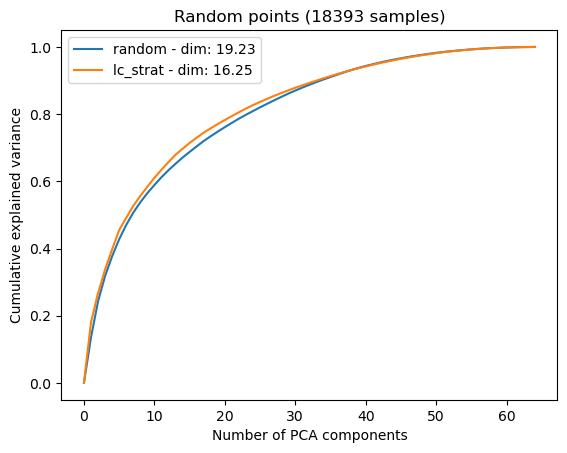

In [47]:
df_use = df_results_centre
import sklearn

# for name, df_sel in zip(['random_sample', 'lc_stratified_sample'], [df_use[df_use['random_sample'] == True], df_use[df_use['lc_stratified_sample'] == True]]):
# for name, df_sel in zip(['random', 'lc_strat'], [df_results_geoclip_random, df_results_geoclip_strat]):
for name, df_sel in zip(['random', 'lc_strat'], [df_random, df_strat]):
    # df_sel = df_results[df_results['lc_stratified_sample'] == True]
    pca = sklearn.decomposition.PCA(n_components=len(EMB_COLS))
    ae_pca = pca.fit_transform(df_sel[EMB_COLS].values)
    cum_expl_var = np.cumsum(pca.explained_variance_ratio_)
    sum_squares = np.sum(np.power(pca.explained_variance_, 2))
    square_sum = np.sum(pca.explained_variance_) ** 2
    dim = float(square_sum / sum_squares)

    print(dim)
    plt.plot([0] + list(cum_expl_var), label=f'{name} - dim: {dim:.2f}')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
# plt.title(f'Centre-only ({len(df_use)} samples)')
plt.title(f'Random points ({len(df_use)} samples)')
plt.legend()

## Concatenate csvs 

In [110]:
## Set data folder to the parent folder with the subfolders for each modality (e.g. alphaearth, dynamicworld, tessera):
data_folder = '/Users/tplas/data/dw_sampled_locations/data_spherical/'

list_ids, modality_folders, gdf_points = du.get_list_complete_ids(data_folder)
print(f'Number of samples: {len(list_ids)}')

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.
Number of samples: 18393


In [134]:
mod = 'aux_geospatial'
folder_load = os.path.join(data_folder, mod, 'source')

contents = [x for x in os.listdir(folder_load) if x.endswith('.csv')]

for i_c, c in enumerate(contents):
    df = pd.read_csv(os.path.join(folder_load, c))
    if i_c == 0:
        df_all = df
    else:        
        df_all = pd.concat([df_all, df], ignore_index=True)

df_all = df_all.sort_values('id').reset_index(drop=True)
df_all = df_all.drop(columns=['coords'])

for name in ['random_sample', 'lc_stratified_sample']:
    ids = gdf_points[gdf_points[name] == 1].id.values
    df_sel = df_all[df_all.id.isin(ids)]
    for m in ['bioclim', 'human_footprint']:
        if m == 'bioclim':
            df_sel_2 = df_sel.drop(columns=[c for c in df_sel.columns if not (c.startswith('bioclim_') or c in ['id'])])
        else:
            df_sel_2 = df_sel.drop(columns=[c for c in df_sel.columns if c.startswith('bioclim_')])
        df_sel_2.to_csv(os.path.join(data_folder, m, f'{name}_{m}.csv'), index=False)


In [135]:
du.load_csv_with_points(parent_folder=data_folder, modality='human_footprint', sample_type='lc_stratified_sample')

,total_population,pop_density,maxdist_road,meandist_road,id
0,0,0,50000,50000,14
1,7519,4615,2153,1295,27
2,1733,1063,1926,1101,37
3,10300,6322,643,115,43
4,465,285,1433,742,45
...,...,...,...,...,...
9660,84,51,1076,455,99941
9661,0,0,3111,2225,99947
9662,0,0,50000,50000,99962
9663,0,0,12039,11189,99965


In [138]:
tmp = du.merge_modalities(parent_folder=data_folder, sample_type='lc_stratified_sample', 
                    zscore_embeddings=False)

Sample random_sample has 9695 data points out of 18393.
Sample lc_stratified_sample has 9693 data points out of 18393.


In [139]:
tmp[1]

{'dynamicworld': ['water',
  'trees',
  'grass',
  'flooded_vegetation',
  'crops',
  'shrub_and_scrub',
  'built',
  'bare',
  'snow_and_ice'],
 'alphaearth': ['alphaearth_emb_0',
  'alphaearth_emb_1',
  'alphaearth_emb_2',
  'alphaearth_emb_3',
  'alphaearth_emb_4',
  'alphaearth_emb_5',
  'alphaearth_emb_6',
  'alphaearth_emb_7',
  'alphaearth_emb_8',
  'alphaearth_emb_9',
  'alphaearth_emb_10',
  'alphaearth_emb_11',
  'alphaearth_emb_12',
  'alphaearth_emb_13',
  'alphaearth_emb_14',
  'alphaearth_emb_15',
  'alphaearth_emb_16',
  'alphaearth_emb_17',
  'alphaearth_emb_18',
  'alphaearth_emb_19',
  'alphaearth_emb_20',
  'alphaearth_emb_21',
  'alphaearth_emb_22',
  'alphaearth_emb_23',
  'alphaearth_emb_24',
  'alphaearth_emb_25',
  'alphaearth_emb_26',
  'alphaearth_emb_27',
  'alphaearth_emb_28',
  'alphaearth_emb_29',
  'alphaearth_emb_30',
  'alphaearth_emb_31',
  'alphaearth_emb_32',
  'alphaearth_emb_33',
  'alphaearth_emb_34',
  'alphaearth_emb_35',
  'alphaearth_emb_36',
